In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Flatten, Dense, Dropout
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


In [3]:
from tensorflow.keras.callbacks import EarlyStopping

def build_1d_hsi_classifier(input_shape, num_classes):
    model = Sequential()

    # Warstwa konwolucyjna 1
    model.add(Conv1D(filters=32, kernel_size=3, padding='same', input_shape=(input_shape, 1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Warstwa konwolucyjna 2
    model.add(Conv1D(filters=64, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Spłaszczenie
    model.add(Flatten())

    # Warstwa w pełni połączona 1
    model.add(Dense(128, activation='relu'))

    # Nowa warstwa w pełni połączona
    model.add(Dense(64, activation='relu'))

    # Warstwa w pełni połączona 2 (warstwa wyjściowa)
    model.add(BatchNormalization())
    model.add(Dense(num_classes, activation='softmax'))

    # Kompilacja modelu
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Early stopping callback

    return model

In [15]:
# Load data
data = sio.loadmat('../data/data/Indian_pines_NS_data.mat')
gt_data = sio.loadmat('../data/gt/Indian_pines_NS_gt.mat')

# Extract hyperspectral image and ground truth
hyper_image = data[list(data.keys())[-1]]  # Assuming last key contains data
ground_truth = gt_data[list(gt_data.keys())[-1]]  # Assuming last key contains ground truth
h, w, p = hyper_image.shape
print(hyper_image.shape)

reshaped_image = hyper_image.reshape(hyper_image.shape[0] * hyper_image.shape[1], hyper_image.shape[2])
reshaped_ground_truth = ground_truth.reshape(ground_truth.shape[0] * ground_truth.shape[1])


(2678, 614, 220)


In [16]:
class_counts = np.bincount(reshaped_ground_truth)
valid_classes = np.where(class_counts > 5000)[0]

mask = np.isin(reshaped_ground_truth, valid_classes)
reshaped_image = reshaped_image[mask]
reshaped_ground_truth = reshaped_ground_truth[mask]




# Remap labels to be sequential
unique_labels, remapped_labels = np.unique(reshaped_ground_truth, return_inverse=True)





#Usuwanie tła
non_zero_indices = remapped_labels != 0
reshaped_image = reshaped_image[non_zero_indices]
remapped_labels = remapped_labels[non_zero_indices]

# Ponownie zakoduj etykiety jako one-hot
unique_labels, remapped_labels = np.unique(remapped_labels, return_inverse=True)





num_classes = len(unique_labels)
print(num_classes)
y_one_hot = to_categorical(remapped_labels, num_classes=num_classes)



# Filter out pixels with no class (assuming class 0 is the "no class" label)
valid_indices = reshaped_ground_truth > 0
background_indices = reshaped_ground_truth == 0

# Downsample each class to a maximum of 5000 samples
filtered_image = []
filtered_labels = []

for class_label in range(0, num_classes):  # Start from 1 to exclude class 0
    class_indices = np.where(remapped_labels == class_label)[0]
    class_indices = class_indices[class_indices != 0]
    if len(class_indices) > 5000:
        sampled_indices = resample(
            class_indices,
            n_samples=5000,
            random_state=42,
            replace=False
        )
    else:
        sampled_indices = class_indices

    filtered_image.append(reshaped_image[sampled_indices])
    filtered_labels.append(y_one_hot[sampled_indices])

# Combine all classes
filtered_image = np.vstack(filtered_image)
# Remove class 0 from the filtered labels and images


# Combine all classes
filtered_image = np.vstack(filtered_image)
filtered_labels = np.vstack(filtered_labels)  # Ensure labels are also combined into a single array

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(filtered_image, filtered_labels, test_size=0.3, random_state=42)


17


In [39]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Tworzenie modelu Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train.argmax(axis=1))  # Dopasowanie modelu (y_train w formie etykiet)

# Predykcja na zbiorze testowym
y_pred_gb = gb_model.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test.argmax(axis=1), y_pred_gb):.2f}")

# Wyświetlenie znaczenia cech
feature_importances = gb_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance from Gradient Boosting')
plt.show()

KeyboardInterrupt: 

In [8]:


# Save feature importances to a .npy file
# np.save("feature_importances.npy", feature_importances)

# Load the saved feature importances
feature_importances = np.load("feature_importances.npy")
print(feature_importances)

[0.02439022 0.02573836 0.02559139 0.02287448 0.01246065 0.01783166
 0.02035941 0.01195743 0.00466317 0.00472579 0.00362153 0.00460772
 0.00213223 0.00245616 0.00405659 0.00386154 0.00518583 0.00114822
 0.00093014 0.00082192 0.0007733  0.00085747 0.00060578 0.00117498
 0.00109281 0.00361223 0.0025372  0.00809428 0.01073399 0.00391022
 0.00418444 0.03332188 0.01351975 0.00644077 0.01137879 0.00706543
 0.0021354  0.00555291 0.00690608 0.00439402 0.00528025 0.004441
 0.00269743 0.00529038 0.00100508 0.00073038 0.00086693 0.0005628
 0.00177533 0.00238533 0.00173692 0.00484239 0.0017157  0.0011633
 0.00073784 0.00141607 0.0008493  0.00719177 0.00655746 0.00153257
 0.00070728 0.00106421 0.0007615  0.00118197 0.00096396 0.00163336
 0.00261174 0.00170027 0.00059418 0.00158928 0.00083231 0.00284209
 0.00170217 0.00096773 0.0003413  0.00254146 0.00677905 0.00952482
 0.00210188 0.00400612 0.00097884 0.00015295 0.00065308 0.00025426
 0.00019427 0.0002955  0.00114155 0.00040806 0.00023784 0.00114154

In [9]:
# Liczba najważniejszych kanałów do zachowania
top_k = 80  # Możesz zmienić tę wartość w zależności od potrzeb

# Znajdź indeksy top_k najważniejszych cech
top_indices = np.argsort(feature_importances)[-top_k:]

# Przytnij dane treningowe i testowe do tych kanałów
X_train_trimmed = X_train[:, top_indices]
X_test_trimmed = X_test[:, top_indices]

print(f"Nowy kształt X_train: {X_train_trimmed.shape}")
print(f"Nowy kształt X_test: {X_test_trimmed.shape}")

Nowy kształt X_train: (59500, 80)
Nowy kształt X_test: (25500, 80)


In [10]:

print(X_test_trimmed.shape)
print(X_train_trimmed.shape)

scaler = StandardScaler()
data_normalized = scaler.fit_transform(X_train_trimmed)
# Normalizacja per kanał:
X_train_trimmed_norm = (X_train_trimmed - X_train_trimmed.mean(axis=0)) / (X_train_trimmed.std(axis=0) + 1e-6)
X_test_trimmed_norm = (X_test_trimmed - X_train_trimmed.mean(axis=0)) / (X_train_trimmed.std(axis=0) + 1e-6)



# PCA jako krok MNF
# pca = PCA(n_components=2)
# data_normalized = pca.fit_transform(data_normalized)
# X_test = pca.transform(X_test)



# scaler_post_PCA = StandardScaler()
# X_train = scaler_post_PCA.fit_transform(data_normalized)
X_test = scaler.transform(X_test_trimmed)

(25500, 80)
(59500, 80)


In [68]:
y_train.shape

(59500, 17)

In [28]:
model = build_1d_hsi_classifier(X_train_trimmed_norm.shape[1], num_classes)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_trimmed_norm, y_train, epochs=15, batch_size=64, validation_split=0.2,shuffle=True)
loss, accuracy = model.evaluate(X_test_trimmed, y_test)
print(f"Test Accuracy: {accuracy:.2f}")


Epoch 1/15


c:\Users\Student\Desktop\mg\Hyperspectral_images_analize\cnnvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


744/744 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3550 - loss: 2.0385 - val_accuracy: 0.4669 - val_loss: 1.6258
Epoch 2/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5047 - loss: 1.5436 - val_accuracy: 0.5400 - val_loss: 1.4314
Epoch 3/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5546 - loss: 1.3778 - val_accuracy: 0.5532 - val_loss: 1.3501
Epoch 4/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5895 - loss: 1.2572 - val_accuracy: 0.5956 - val_loss: 1.2540
Epoch 5/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6218 - loss: 1.1606 - val_accuracy: 0.6132 - val_loss: 1.1722
Epoch 6/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6422 - loss: 1.1027 - val_accuracy: 0.6220 - val_loss: 1.1444
Epoch 7/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6566 - loss: 1.0438 - val_accuracy: 0.6395 - val_loss: 1.1080
Epoch 8/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6753 - loss: 0.9909 - val_accuracy: 0.6361

1860/1860 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
              precision    recall  f1-score   support

           0       0.79      0.64      0.71      3514
           1       0.77      0.52      0.62      3511
           2       0.81      0.58      0.67      3523
           3       0.56      0.72      0.63      3548
           4       0.54      0.65      0.59      3502
           5       0.84      0.79      0.82      3499
           6       0.82      0.83      0.82      3453
           7       0.85      0.93      0.89      3441
           8       0.88      0.87      0.87      3502
           9       0.83      0.73      0.78      3512
          10       0.85      0.76      0.80      3481
          11       0.77      0.68      0.72      3523
          12       0.62      0.75      0.68      3474
          13       0.66      0.81      0.72      3474
          14       0.84      0.93      0.88      3538
          15       0.89      0.80      0.84      3500
          16       0.76      0.91     

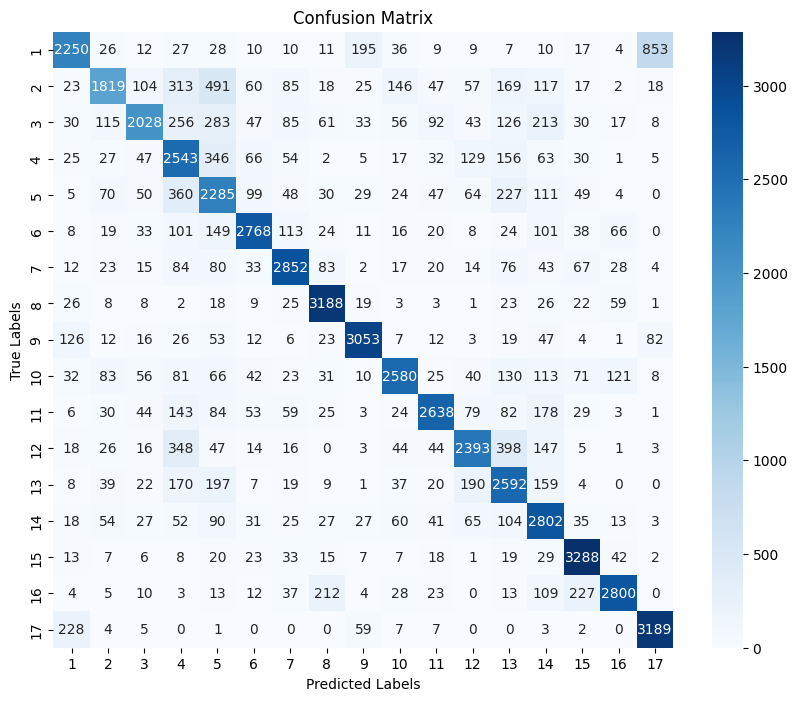

In [29]:
## TRAIN DATA
# 
y_pred = model.predict(X_train_trimmed_norm)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_train, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [32]:
# Generate classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_test, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_3" is incompatible with the layer: expected axis -1 of input shape to have value 5120, but received input with shape (32, 14080)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 220), dtype=uint16)
  • training=False
  • mask=None

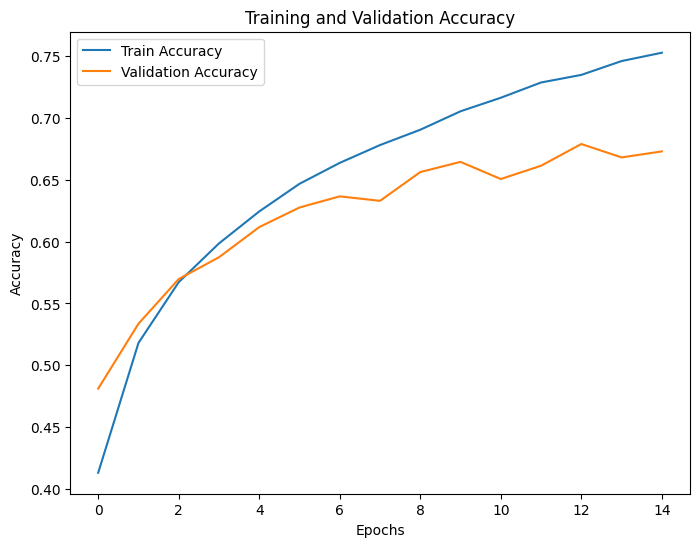

In [ ]:
# Plot training and validation accuracy
# history = model.history
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## More epochs with same dataset

c:\Users\Student\Desktop\mg\Hyperspectral_images_analize\cnnvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3435 - loss: 2.0921 - val_accuracy: 0.4744 - val_loss: 1.6476
Epoch 2/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5006 - loss: 1.5602 - val_accuracy: 0.5327 - val_loss: 1.4497
Epoch 3/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5501 - loss: 1.3896 - val_accuracy: 0.5603 - val_loss: 1.3624
Epoch 4/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5887 - loss: 1.2679 - val_accuracy: 0.5905 - val_loss: 1.2529
Epoch 5/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6169 - loss: 1.1804 - val_accuracy: 0.6082 - val_loss: 1.2032
Epoch 6/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6390 - loss: 1.1131 - val_accuracy: 0.5941 - val_loss: 1.2174
Epoch 7/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6592 - loss: 1.0381 - val_accuracy: 0.6329 - val_loss: 1.1181
Epoch 8/60
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6710 - loss: 1.0004 - val_accur

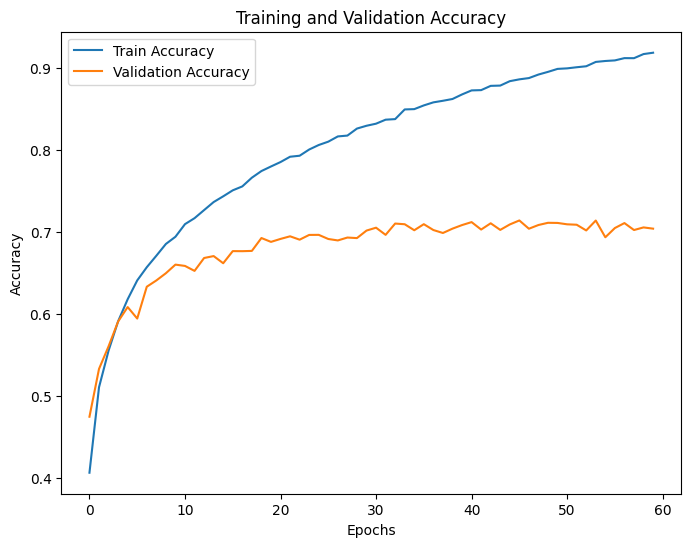

In [11]:
model = build_1d_hsi_classifier(X_train_trimmed_norm.shape[1], num_classes)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train_trimmed_norm, y_train, epochs=60, batch_size=64, validation_split=0.2)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1860/1860 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      3514
           1       0.86      0.87      0.86      3511
           2       0.94      0.77      0.85      3523
           3       0.80      0.86      0.83      3548
           4       0.82      0.81      0.81      3502
           5       0.95      0.90      0.93      3499
           6       0.90      0.93      0.92      3453
           7       0.97      0.93      0.95      3441
           8       0.91      0.97      0.94      3502
           9       0.91      0.93      0.92      3512
          10       0.96      0.86      0.90      3481
          11       0.88      0.89      0.88      3523
          12       0.82      0.90      0.86      3474
          13       0.84      0.90      0.87      3474
          14       0.93      0.97      0.95      3538
          15       0.93      0.94      0.94      3500
          16       0.92      0.85     

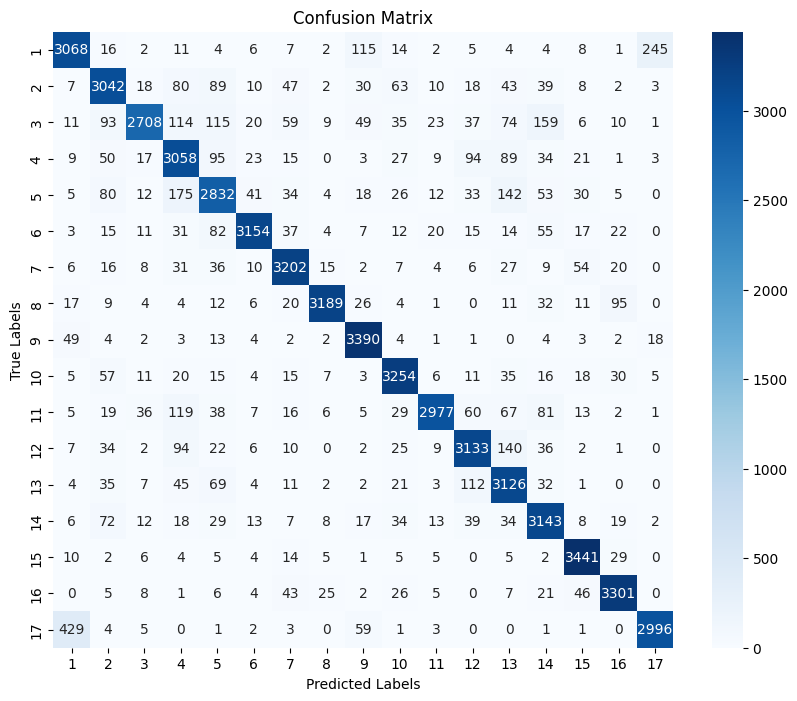

In [12]:
## TRAIN DATA
# 
y_pred = model.predict(X_train_trimmed_norm)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_train, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      1486
           1       0.58      0.56      0.57      1489
           2       0.72      0.49      0.58      1477
           3       0.53      0.62      0.57      1452
           4       0.52      0.51      0.51      1498
           5       0.83      0.74      0.78      1501
           6       0.76      0.79      0.77      1547
           7       0.91      0.80      0.85      1559
           8       0.78      0.88      0.83      1498
           9       0.69      0.74      0.71      1488
          10       0.82      0.66      0.73      1519
          11       0.66      0.67      0.67      1477
          12       0.59      0.69      0.64      1526
          13       0.64      0.69      0.66      1526
          14       0.81      0.89      0.85      1462
          15       0.76      0.83      0.79      1500
          16       0.86      0.80      0

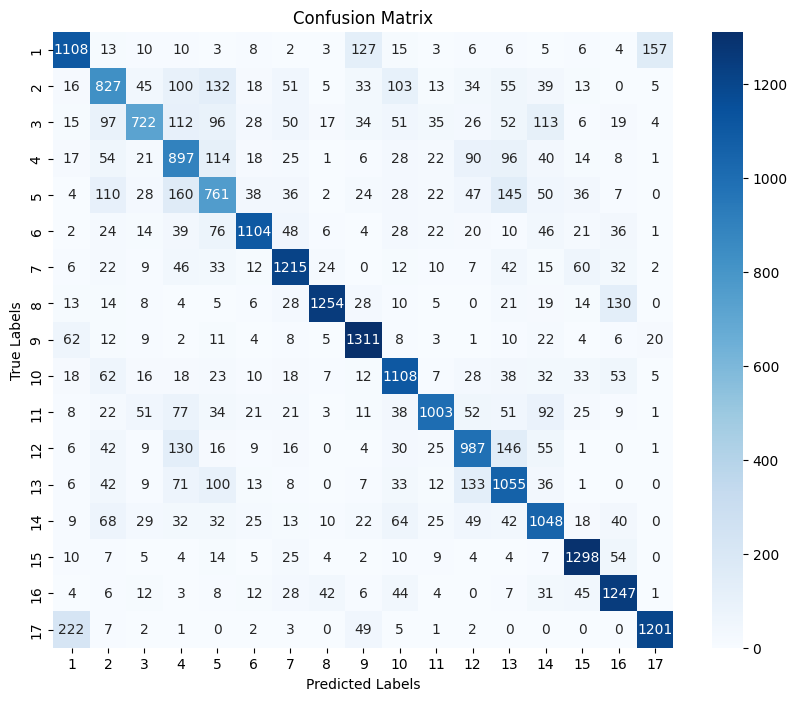

In [13]:
# Generate classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=-1)
y_true_classes = np.argmax(y_test, axis=-1)
# Print classification report
print(classification_report(y_true_classes, y_pred_classes))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()